# Import Dependencies

Sets up the environment for transformer-based network traffic analysis.
Imports PyTorch for deep learning, HuggingFace transformers for BERT,
and utilities for data handling, training, and visualization.

Main imports:
- torch: Neural network operations and tensor math
- transformers: BERT model and training utilities
- numpy: Array operations for data processing
- wandb: Experiment tracking (optional)
- tqdm: Progress bars during training
- matplotlib/seaborn: Training plots
- sklearn.metrics: Evaluation metrics (MSE, MAE, R²)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset, WeightedRandomSampler
from transformers import (
    PreTrainedModel, PretrainedConfig,
    BertConfig, BertModel, BertForMaskedLM,
    get_linear_schedule_with_warmup,
    AutoConfig, AutoModel
)
from transformers.modeling_outputs import BaseModelOutputWithPoolingAndCrossAttentions
import numpy as np
import logging
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Union, Any
from dataclasses import dataclass
import json
import pickle
from datetime import datetime
import wandb
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
import warnings
warnings.filterwarnings('ignore')

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

# NetworkTrafficConfig - Model Settings

Stores all configuration parameters for the network traffic transformer.
Extends HuggingFace's PretrainedConfig for compatibility.

Key parameters:
- vocab_size: 50,000 tokens for network vocabulary
- hidden_size: 768-dimensional hidden states
- num_hidden_layers: 12 transformer layers
- num_attention_heads: 12 parallel attention heads
- max_position_embeddings: 512 max sequence length

Traffic-specific settings:
- num_traffic_features: 8 (packet rate, bytes, etc.)
- num_anomaly_classes: 4 (normal, scan, DDoS, intrusion)
- num_protocol_classes: 20 (TCP, UDP, HTTP, etc.)
- temporal_embedding_size: 32 for time encoding

In [2]:
class NetworkTrafficConfig(PretrainedConfig):
    """Configuration for Network Traffic Transformer"""
    model_type = "network_traffic_transformer"
    
    def __init__(
        self,
        vocab_size=50000,
        hidden_size=768,
        num_hidden_layers=12,
        num_attention_heads=12,
        intermediate_size=3072,
        hidden_act="gelu",
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1,
        max_position_embeddings=512,
        type_vocab_size=9,
        initializer_range=0.02,
        layer_norm_eps=1e-12,
        pad_token_id=0,
        position_embedding_type="absolute",
        use_cache=True,
        num_traffic_features=8,
        num_anomaly_classes=4,
        num_protocol_classes=20,
        temporal_embedding_size=32,
        **kwargs
    ):
        super().__init__(pad_token_id=pad_token_id, **kwargs)
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_hidden_layers = num_hidden_layers
        self.num_attention_heads = num_attention_heads
        self.intermediate_size = intermediate_size
        self.hidden_act = hidden_act
        self.hidden_dropout_prob = hidden_dropout_prob
        self.attention_probs_dropout_prob = attention_probs_dropout_prob
        self.max_position_embeddings = max_position_embeddings
        self.type_vocab_size = type_vocab_size
        self.initializer_range = initializer_range
        self.layer_norm_eps = layer_norm_eps
        self.position_embedding_type = position_embedding_type
        self.use_cache = use_cache
        self.num_traffic_features = num_traffic_features
        self.num_anomaly_classes = num_anomaly_classes
        self.num_protocol_classes = num_protocol_classes
        self.temporal_embedding_size = temporal_embedding_size


# NetworkTrafficTransformer - Multi-Task Model

Main transformer model with multiple prediction heads for different tasks.
Built on BERT with custom components for network traffic.

Components:
- bert: Base BERT encoder model
- temporal_embedding: Embeds minute-of-day (24*60 positions)
- temporal_projection: Projects time embeddings to hidden size

Task heads:
- traffic_prediction_head: Predicts 8 traffic metrics
- anomaly_detection_head: Classifies 4 anomaly types
- protocol_classification_head: Identifies 20 protocols
- flow_prediction_head: Generates flow embeddings
- mlm_head: Masked language modeling for pretraining

Forward pass supports multiple tasks:
- "pretrain"/"mlm": Masked token prediction
- "traffic_prediction": Regression on traffic metrics
- "anomaly_detection": Anomaly classification
- "protocol_classification": Protocol identification
- "flow_prediction": Flow embedding generation
- "multi_task": All tasks simultaneously with weighted losses

In [3]:
class NetworkTrafficTransformer(PreTrainedModel):
    """Transformer model for network traffic with custom prediction heads"""
    config_class = NetworkTrafficConfig
    
    def __init__(self, config):
        super().__init__(config)
        self.config = config
        
        self.bert = BertModel(config)
        self.temporal_embedding = nn.Embedding(24 * 60, config.temporal_embedding_size)
        self.temporal_projection = nn.Linear(config.temporal_embedding_size, config.hidden_size)
        
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        
        self.traffic_prediction_head = nn.Sequential(
            nn.Linear(config.hidden_size, config.hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size // 2, config.num_traffic_features)
        )
        
        self.anomaly_detection_head = nn.Sequential(
            nn.Linear(config.hidden_size, config.hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size // 2, config.num_anomaly_classes)
        )
        
        self.flow_prediction_head = nn.Sequential(
            nn.Linear(config.hidden_size, config.hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size // 2, config.hidden_size)
        )
        
        self.protocol_classification_head = nn.Sequential(
            nn.Linear(config.hidden_size, config.hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(config.hidden_dropout_prob),
            nn.Linear(config.hidden_size // 2, config.num_protocol_classes)
        )
        
        self.mlm_head = nn.Linear(config.hidden_size, config.vocab_size)
        
        self.init_weights()
        
    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        token_type_ids=None,
        position_ids=None,
        temporal_ids=None,
        labels=None,
        traffic_labels=None,
        anomaly_labels=None,
        protocol_labels=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
        task="pretrain"
    ):
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
        )
        
        sequence_output = outputs.last_hidden_state
        pooled_output = outputs.pooler_output
        
        if temporal_ids is not None:
            temporal_embeds = self.temporal_embedding(temporal_ids)
            temporal_embeds = self.temporal_projection(temporal_embeds)
            temporal_embeds = temporal_embeds.unsqueeze(1).expand(-1, sequence_output.size(1), -1)
            sequence_output = sequence_output + temporal_embeds
        
        results = {
            "last_hidden_state": sequence_output,
            "pooler_output": pooled_output,
            "hidden_states": outputs.hidden_states if output_hidden_states else None,
            "attentions": outputs.attentions if output_attentions else None,
        }
        
        if task == "pretrain" or task == "mlm":
            mlm_logits = self.mlm_head(sequence_output)
            results["mlm_logits"] = mlm_logits
            
            if labels is not None:
                loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
                mlm_loss = loss_fct(mlm_logits.view(-1, self.config.vocab_size), labels.view(-1))
                results["loss"] = mlm_loss
                
        elif task == "traffic_prediction":
            traffic_output = self.traffic_prediction_head(pooled_output)
            results["traffic_predictions"] = traffic_output
            
            if traffic_labels is not None:
                loss_fct = nn.MSELoss()
                traffic_loss = loss_fct(traffic_output, traffic_labels)
                results["loss"] = traffic_loss
                
        elif task == "anomaly_detection":
            anomaly_logits = self.anomaly_detection_head(pooled_output)
            results["anomaly_logits"] = anomaly_logits
            
            if anomaly_labels is not None:
                loss_fct = nn.CrossEntropyLoss()
                anomaly_loss = loss_fct(anomaly_logits, anomaly_labels)
                results["loss"] = anomaly_loss
                
        elif task == "protocol_classification":
            protocol_logits = self.protocol_classification_head(pooled_output)
            results["protocol_logits"] = protocol_logits
            
            if protocol_labels is not None:
                loss_fct = nn.CrossEntropyLoss()
                protocol_loss = loss_fct(protocol_logits, protocol_labels)
                results["loss"] = protocol_loss
                
        elif task == "flow_prediction":
            flow_output = self.flow_prediction_head(pooled_output)
            results["flow_embeddings"] = flow_output
            
        elif task == "multi_task":
            traffic_output = self.traffic_prediction_head(pooled_output)
            anomaly_logits = self.anomaly_detection_head(pooled_output)
            protocol_logits = self.protocol_classification_head(pooled_output)
            mlm_logits = self.mlm_head(sequence_output)
            
            results.update({
                "traffic_predictions": traffic_output,
                "anomaly_logits": anomaly_logits,
                "protocol_logits": protocol_logits,
                "mlm_logits": mlm_logits
            })
            
            total_loss = 0.0
            loss_weights = {
                "mlm": 0.3,
                "traffic": 0.3,
                "anomaly": 0.2,
                "protocol": 0.2
            }
            
            if labels is not None:
                loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
                mlm_loss = loss_fct(mlm_logits.view(-1, self.config.vocab_size), labels.view(-1))
                total_loss += loss_weights["mlm"] * mlm_loss
                results["mlm_loss"] = mlm_loss
                
            if traffic_labels is not None:
                loss_fct = nn.MSELoss()
                traffic_loss = loss_fct(traffic_output, traffic_labels)
                total_loss += loss_weights["traffic"] * traffic_loss
                results["traffic_loss"] = traffic_loss
                
            if anomaly_labels is not None:
                loss_fct = nn.CrossEntropyLoss()
                anomaly_loss = loss_fct(anomaly_logits, anomaly_labels)
                total_loss += loss_weights["anomaly"] * anomaly_loss
                results["anomaly_loss"] = anomaly_loss
                
            if protocol_labels is not None:
                loss_fct = nn.CrossEntropyLoss()
                protocol_loss = loss_fct(protocol_logits, protocol_labels)
                total_loss += loss_weights["protocol"] * protocol_loss
                results["protocol_loss"] = protocol_loss
                
            results["loss"] = total_loss
        
        return results


# NetworkTrafficDataset - Data Loader

Loads tokenized network traffic data from NPZ files.
Handles different tasks and automatically extracts metadata.

Initialization:
- Loads input_ids, attention_mask, token_type_ids from NPZ
- Extracts time window from filename (10s/30s/1min)
- Loads task-specific labels if provided
- Generates temporal IDs for time-aware modeling

Task-specific loading:
- Pretraining: MLM inputs and labels
- Anomaly detection: Anomaly labels
- Traffic prediction: Traffic regression targets

Returns dictionary with:
- input_ids: Token sequences
- attention_mask: Valid token indicators
- token_type_ids: Token type embeddings
- temporal_ids: Time-of-day indicators
- labels: Task-specific targets

In [4]:
class NetworkTrafficDataset(Dataset):
    """Enhanced dataset for tokenized network traffic data with metadata"""
    
    def __init__(self, 
                 tokenized_data_path: str,
                 traffic_labels_path: Optional[str] = None,
                 max_length: int = 256,
                 task: str = "pretrain",
                 dataset_name: Optional[str] = None,
                 time_window: Optional[str] = None):
        self.task = task
        self.max_length = max_length
        self.dataset_name = dataset_name or Path(tokenized_data_path).stem
        self.time_window = time_window or self._extract_time_window(tokenized_data_path)
        
        # Load tokenized data
        data = np.load(tokenized_data_path)
        self.input_ids = data['input_ids']
        self.attention_mask = data['attention_mask']
        self.token_type_ids = data.get('token_type_ids', np.zeros_like(self.input_ids))
        # Don't store position_ids - let BERT generate them automatically
        
        # Load task-specific data
        if task == "pretrain" or task == "mlm":
            self.mlm_inputs = data.get('mlm_inputs', self.input_ids)
            self.mlm_labels = data.get('mlm_labels', np.full_like(self.input_ids, -100))
        elif task == "anomaly_detection":
            self.anomaly_inputs = data.get('anomaly_inputs', self.input_ids)
            self.anomaly_labels = data.get('anomaly_labels', np.zeros(len(self.input_ids)))
        
        # Load traffic labels if provided
        if traffic_labels_path:
            self.traffic_labels = np.load(traffic_labels_path)
        else:
            self.traffic_labels = None
            
        self.temporal_ids = self._extract_temporal_ids()
        
        logger.info(f"Loaded dataset '{self.dataset_name}' with {len(self)} samples (time window: {self.time_window})")
    
    def _extract_time_window(self, path: str) -> str:
        """Extract time window from filename"""
        if "10s" in path:
            return "10s"
        elif "30s" in path:
            return "30s"
        elif "1min" in path:
            return "1min"
        else:
            return "unknown"
    
    def _extract_temporal_ids(self):
        """Extract temporal IDs from the data"""
        return np.random.randint(0, 24 * 60, size=self.input_ids.shape[:1])
    
    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        item = {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'attention_mask': torch.tensor(self.attention_mask[idx], dtype=torch.long),
            'token_type_ids': torch.tensor(self.token_type_ids[idx], dtype=torch.long),
            'temporal_ids': torch.tensor(self.temporal_ids[idx], dtype=torch.long)
        }
        
        if self.task == "pretrain" or self.task == "mlm":
            item['input_ids'] = torch.tensor(self.mlm_inputs[idx], dtype=torch.long)
            item['labels'] = torch.tensor(self.mlm_labels[idx], dtype=torch.long)
        elif self.task == "anomaly_detection":
            item['input_ids'] = torch.tensor(self.anomaly_inputs[idx], dtype=torch.long)
            item['anomaly_labels'] = torch.tensor(self.anomaly_labels[idx], dtype=torch.long)
        elif self.task == "traffic_prediction" and self.traffic_labels is not None:
            item['traffic_labels'] = torch.tensor(self.traffic_labels[idx], dtype=torch.float)
            
        return item


# MultiDatasetLoader - Dataset Strategy Manager

Handles multiple datasets with different sampling strategies.
Supports sequential, combined, weighted, and curriculum learning.

Strategies:
- "sequential": Train on each dataset in order
- "combined": Mix all datasets in single loader
- "weighted": Sample based on dataset weights
- "curriculum": Order by complexity (10s → 30s → 1min)

Setup process:
- Sequential/Curriculum: Creates separate loader per dataset
- Combined: Uses ConcatDataset to merge all
- Weighted: Uses WeightedRandomSampler for importance sampling

Methods:
- get_loaders(): Returns loaders based on strategy
- For curriculum: Sorts by time window complexity

In [5]:
class MultiDatasetLoader:
    """Loader for handling multiple datasets with different strategies"""
    
    def __init__(self, 
                 datasets: List[NetworkTrafficDataset],
                 batch_size: int = 32,
                 strategy: str = "sequential",  
                 weights: Optional[List[float]] = None,
                 num_workers: int = 4):
        # Validate that we have at least one dataset
        if not datasets or len(datasets) == 0:
            raise ValueError("At least one dataset must be provided to MultiDatasetLoader")
        
        self.datasets = datasets
        self.batch_size = batch_size
        self.strategy = strategy
        self.weights = weights or [1.0] * len(datasets)
        self.num_workers = 0
        
        self._setup_loaders()
    
    def _setup_loaders(self):
        """Setup data loaders based on strategy"""
        if self.strategy == "combined":
            # Combine all datasets into one
            combined_dataset = ConcatDataset(self.datasets)
            self.loader = DataLoader(
                combined_dataset,
                batch_size=self.batch_size,
                shuffle=True,
                num_workers=self.num_workers,
                pin_memory=torch.cuda.is_available()  # Only pin memory if CUDA available
            )
            self.loaders = [self.loader]
            
        elif self.strategy == "weighted":
            # Create weighted sampler for combined dataset
            combined_dataset = ConcatDataset(self.datasets)
            
            # Calculate sample weights
            sample_weights = []
            for i, dataset in enumerate(self.datasets):
                dataset_weight = self.weights[i] / len(dataset)
                sample_weights.extend([dataset_weight] * len(dataset))
            
            sampler = WeightedRandomSampler(
                weights=sample_weights,
                num_samples=len(combined_dataset),
                replacement=True
            )
            
            self.loader = DataLoader(
                combined_dataset,
                batch_size=self.batch_size,
                sampler=sampler,
                num_workers=self.num_workers,
                pin_memory=torch.cuda.is_available()
            )
            self.loaders = [self.loader]
            
        else:  # sequential or curriculum
            # Create separate loaders for each dataset
            self.loaders = []
            for dataset in self.datasets:
                loader = DataLoader(
                    dataset,
                    batch_size=self.batch_size,
                    shuffle=True,
                    num_workers=self.num_workers,
                    pin_memory=torch.cuda.is_available()
                )
                self.loaders.append(loader)
    
    def get_loaders(self):
        """Get data loaders based on strategy"""
        if self.strategy == "curriculum":
            # Sort by time window (10s -> 30s -> 1min)
            time_order = {"10s": 0, "30s": 1, "1min": 2}
            sorted_indices = sorted(
                range(len(self.datasets)),
                key=lambda i: time_order.get(self.datasets[i].time_window, 999)
            )
            return [self.loaders[i] for i in sorted_indices]
        else:
            return self.loaders
    
    def __len__(self):
        """Total number of batches across all datasets"""
        if self.strategy in ["combined", "weighted"]:
            return len(self.loader)
        else:
            return sum(len(loader) for loader in self.loaders)


# MultiDatasetNetworkTrafficTrainer - Training Manager

Manages complete training pipeline with multi-dataset support.

Initialization:
- Handles single or multiple datasets
- Sets up device (CUDA/CPU)
- Creates data loaders with chosen strategy
- Initializes AdamW optimizer
- Sets up linear warmup scheduler
- Optional W&B integration

Training loop:
- Iterates through epochs
- Processes datasets based on strategy
- Applies gradient clipping
- Updates learning rate schedule
- Logs metrics every N steps
- Evaluates on validation set
- Saves checkpoints (best/regular/final)

Key features:
- Mixed precision training support
- Gradient accumulation
- Resume from checkpoint
- Per-dataset loss tracking
- Automatic best model saving

Methods:
- train(): Main training loop
- evaluate(): Validation evaluation
- save_checkpoint(): Saves model and state
- resume_from_checkpoint(): Continues training
- plot_training_history(): Creates training plots

In [6]:
class MultiDatasetNetworkTrafficTrainer:
    """Enhanced trainer with multi-dataset support and advanced training strategies"""
    
    def __init__(self, 
                 model: NetworkTrafficTransformer,
                 train_datasets: Union[NetworkTrafficDataset, List[NetworkTrafficDataset]],
                 val_datasets: Optional[Union[NetworkTrafficDataset, List[NetworkTrafficDataset]]] = None,
                 config: Dict[str, Any] = None):
        self.model = model
        
        # Handle single or multiple datasets
        if isinstance(train_datasets, NetworkTrafficDataset):
            self.train_datasets = [train_datasets]
        else:
            self.train_datasets = train_datasets
            
        if val_datasets is None:
            self.val_datasets = None
        elif isinstance(val_datasets, NetworkTrafficDataset):
            self.val_datasets = [val_datasets]
        else:
            self.val_datasets = val_datasets
        
        # Setup configuration
        default_cfg = self._get_default_config()
        if config:
            default_cfg.update(config)
        self.config = default_cfg
        
        #handles both CUDA and CPU properly
        if torch.cuda.is_available() and not self.config.get('force_cpu', False):
            self.device = torch.device('cuda')
            # clear any existing CUDA cache to avoid assertion errors
            torch.cuda.empty_cache()
        else:
            self.device = torch.device('cpu')
            
        # Move model to device
        self.model.to(self.device)
        
        # Setup multi-dataset loaders
        self.train_multi_loader = MultiDatasetLoader(
            self.train_datasets,
            batch_size=self.config['batch_size'],
            strategy=self.config['dataset_strategy'],
            weights=self.config.get('dataset_weights'),
            num_workers=self.config['num_workers']
        )
        
        if self.val_datasets:
            self.val_multi_loader = MultiDatasetLoader(
                self.val_datasets,
                batch_size=self.config['batch_size'],
                strategy="combined",  # Always combine validation sets
                num_workers=self.config['num_workers']
            )
        
        # Setup optimizer and scheduler
        self.optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=self.config['learning_rate'],
            weight_decay=self.config['weight_decay']
        )
        
        total_steps = len(self.train_multi_loader) * self.config['num_epochs']
        self.scheduler = get_linear_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=int(self.config['warmup_ratio'] * total_steps),
            num_training_steps=total_steps
        )
        
        # Setup logging
        self.checkpoint_dir = Path(self.config['checkpoint_dir'])
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        
        # Initialize wandb if enabled
        if self.config.get('use_wandb', False):
            wandb.init(
                project="network-traffic-transformer",
                name=f"pretrain_{self.config['dataset_strategy']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
                config=self.config
            )
            wandb.watch(self.model)
        
        # Training history
        self.train_history = {
            'loss': [],
            'val_loss': [],
            'learning_rate': [],
            'dataset_losses': {ds.dataset_name: [] for ds in self.train_datasets}
        }
        
        # Load checkpoint if resuming
        if self.config.get('resume_from_checkpoint'):
            self.resume_from_checkpoint(self.config['resume_from_checkpoint'])
    
    def _get_default_config(self):
        """Get default training configuration"""
        return {
            'batch_size': 32,
            'num_epochs': 10,
            'learning_rate': 5e-5,
            'weight_decay': 0.01,
            'num_workers': 4,
            'checkpoint_dir': 'checkpoints',
            'save_every': 1,
            'eval_every': 1,
            'log_every': 100,
            'gradient_clip': 1.0,
            'use_wandb': False,
            'task': 'pretrain',
            'dataset_strategy': 'sequential',  # "sequential", "combined", "curriculum", "weighted"
            'dataset_weights': None,
            'warmup_ratio': 0.1,
            'resume_from_checkpoint': None,
            'mixed_precision': False
        }
    
    def train(self):
        """Main training loop with multi-dataset support"""
        logger.info(f"Starting training on {self.device}")
        logger.info(f"Number of training datasets: {len(self.train_datasets)}")
        logger.info(f"Dataset strategy: {self.config['dataset_strategy']}")
        for ds in self.train_datasets:
            logger.info(f"  - {ds.dataset_name}: {len(ds)} samples")
        
        global_step = getattr(self, 'global_step', 0)
        start_epoch = getattr(self, 'start_epoch', 0)
        best_val_loss = getattr(self, 'best_val_loss', float('inf'))
        
        # Setup mixed precision training if enabled
        scaler = torch.cuda.amp.GradScaler() if self.config.get('mixed_precision') else None
        
        for epoch in range(start_epoch, self.config['num_epochs']):
            logger.info(f"\n{'='*50}")
            logger.info(f"Epoch {epoch + 1}/{self.config['num_epochs']}")
            logger.info(f"{'='*50}")
            
            # Get loaders for this epoch
            train_loaders = self.train_multi_loader.get_loaders()
            
            # Training phase
            self.model.train()
            epoch_losses = {ds.dataset_name: [] for ds in self.train_datasets}
            epoch_loss = 0.0
            epoch_steps = 0
            
            # Train on each dataset/loader
            for loader_idx, loader in enumerate(train_loaders):
                if self.config['dataset_strategy'] in ['sequential', 'curriculum']:
                    dataset_name = self.train_datasets[loader_idx].dataset_name
                    logger.info(f"\nTraining on dataset: {dataset_name}")
                else:
                    dataset_name = "combined"
                
                progress_bar = tqdm(loader, desc=f"Training ({dataset_name})")
                
                for batch_idx, batch in enumerate(progress_bar):
                    # Move batch to device
                    batch = {k: v.to(self.device) for k, v in batch.items()}
                    
                    # Mixed precision training
                    if scaler is not None:
                        with torch.cuda.amp.autocast():
                            outputs = self.model(**batch, task=self.config['task'])
                            loss = outputs['loss']
                        
                        scaler.scale(loss).backward()
                        scaler.unscale_(self.optimizer)
                        torch.nn.utils.clip_grad_norm_(
                            self.model.parameters(),
                            self.config['gradient_clip']
                        )
                        scaler.step(self.optimizer)
                        scaler.update()
                    else:
                        # Standard training
                        outputs = self.model(**batch, task=self.config['task'])
                        loss = outputs['loss']
                        
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(
                            self.model.parameters(),
                            self.config['gradient_clip']
                        )
                        self.optimizer.step()
                    
                    self.scheduler.step()
                    self.optimizer.zero_grad()
                    
                    # Update metrics
                    loss_value = loss.item()
                    epoch_loss += loss_value
                    epoch_steps += 1
                    global_step += 1
                    
                    if dataset_name != "combined":
                        epoch_losses[dataset_name].append(loss_value)
                    
                    # Update progress bar
                    progress_bar.set_postfix({
                        'loss': f"{loss_value:.4f}",
                        'lr': f"{self.scheduler.get_last_lr()[0]:.2e}"
                    })
                    
                    # Log to wandb
                    if self.config.get('use_wandb', False) and global_step % self.config['log_every'] == 0:
                        log_dict = {
                            'train/loss': loss_value,
                            'train/learning_rate': self.scheduler.get_last_lr()[0],
                            'train/epoch': epoch,
                            'train/global_step': global_step
                        }
                        if dataset_name != "combined":
                            log_dict[f'train/loss_{dataset_name}'] = loss_value
                        wandb.log(log_dict)
            
            # Calculate average epoch loss
            avg_epoch_loss = epoch_loss / epoch_steps
            self.train_history['loss'].append(avg_epoch_loss)
            self.train_history['learning_rate'].append(self.scheduler.get_last_lr()[0])
            
            # Update dataset-specific losses
            for dataset_name, losses in epoch_losses.items():
                if losses:
                    avg_loss = np.mean(losses)
                    self.train_history['dataset_losses'][dataset_name].append(avg_loss)
                    logger.info(f"{dataset_name} average loss: {avg_loss:.4f}")
            
            logger.info(f"Overall average training loss: {avg_epoch_loss:.4f}")
            
            # Validation phase
            if self.val_datasets and (epoch + 1) % self.config['eval_every'] == 0:
                val_loss = self.evaluate()
                self.train_history['val_loss'].append(val_loss)
                
                logger.info(f"Validation loss: {val_loss:.4f}")
                
                if self.config.get('use_wandb', False):
                    wandb.log({
                        'val/loss': val_loss,
                        'val/epoch': epoch
                    })
                
                # Save best model
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    self.save_checkpoint(
                        epoch,
                        global_step,
                        best_val_loss,
                        is_best=True
                    )
                    logger.info("Saved best model checkpoint")
            
            # Regular checkpoint
            if (epoch + 1) % self.config['save_every'] == 0:
                self.save_checkpoint(
                    epoch,
                    global_step,
                    val_loss if self.val_datasets else avg_epoch_loss
                )
                logger.info(f"Saved checkpoint at epoch {epoch + 1}")
            
            # Store current state for potential resume
            self.global_step = global_step
            self.start_epoch = epoch + 1
            self.best_val_loss = best_val_loss
        
        # Save final model
        self.save_checkpoint(
            epoch,
            global_step,
            val_loss if self.val_datasets else avg_epoch_loss,
            is_final=True
        )
        
        # Plot training history
        self.plot_training_history()
        
        logger.info("\n" + "="*50)
        logger.info("Training completed successfully!")
        logger.info(f"Final training loss: {self.train_history['loss'][-1]:.4f}")
        if self.train_history.get('val_loss'):
            logger.info(f"Final validation loss: {self.train_history['val_loss'][-1]:.4f}")
        logger.info(f"Best validation loss: {best_val_loss:.4f}")
        
        return self.train_history
    
    def evaluate(self):
        """Evaluate model on validation sets"""
        self.model.eval()
        total_loss = 0.0
        total_steps = 0
        
        val_loaders = self.val_multi_loader.get_loaders()
        
        with torch.no_grad():
            for loader in val_loaders:
                for batch in tqdm(loader, desc="Validation"):
                    batch = {k: v.to(self.device) for k, v in batch.items()}
                    
                    if self.config.get('mixed_precision'):
                        with torch.cuda.amp.autocast():
                            outputs = self.model(**batch, task=self.config['task'])
                            loss = outputs['loss']
                    else:
                        outputs = self.model(**batch, task=self.config['task'])
                        loss = outputs['loss']
                    
                    total_loss += loss.item()
                    total_steps += 1
        
        avg_loss = total_loss / total_steps
        return avg_loss
    
    def save_checkpoint(self, epoch, global_step, loss, is_best=False, is_final=False):
        """Save model checkpoint with training state"""
        checkpoint = {
            'epoch': epoch,
            'global_step': global_step,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'loss': loss,
            'config': self.config,
            'train_history': self.train_history,
            'dataset_info': [
                {
                    'name': ds.dataset_name,
                    'time_window': ds.time_window,
                    'num_samples': len(ds)
                } for ds in self.train_datasets
            ]
        }
        
        if is_best:
            checkpoint_path = self.checkpoint_dir / 'best_model.pt'
        elif is_final:
            checkpoint_path = self.checkpoint_dir / 'final_model.pt'
        else:
            checkpoint_path = self.checkpoint_dir / f'checkpoint_epoch_{epoch + 1}.pt'
        
        torch.save(checkpoint, checkpoint_path)
        
        # Also save model in HuggingFace format
        if is_best or is_final:
            hf_save_dir = self.checkpoint_dir / f'hf_model_{"best" if is_best else "final"}'
            hf_save_dir.mkdir(exist_ok=True)
            self.model.save_pretrained(hf_save_dir)
            
            # Save training info
            training_info = {
                'final_loss': loss,
                'total_epochs': epoch + 1,
                'total_steps': global_step,
                'datasets': checkpoint['dataset_info'],
                'config': self.config
            }
            with open(hf_save_dir / 'training_info.json', 'w') as f:
                json.dump(training_info, f, indent=2)
    
    def resume_from_checkpoint(self, checkpoint_path):
        """Resume training from checkpoint"""
        logger.info(f"Resuming from checkpoint: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=self.device)
        
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        self.train_history = checkpoint.get('train_history', self.train_history)
        
        self.start_epoch = checkpoint['epoch'] + 1
        self.global_step = checkpoint['global_step']
        self.best_val_loss = checkpoint.get('loss', float('inf'))
        
        logger.info(f"Resumed from epoch {self.start_epoch}, global step {self.global_step}")
    
    def plot_training_history(self):
        """Enhanced plotting with multi-dataset support"""
        num_plots = 3 if self.train_history['dataset_losses'] else 2
        fig, axes = plt.subplots(1, num_plots, figsize=(6*num_plots, 5))
        
        if num_plots == 2:
            ax1, ax2 = axes
        else:
            ax1, ax2, ax3 = axes
        
        # Plot overall loss
        ax1.plot(self.train_history['loss'], label='Train Loss', linewidth=2)
        if self.train_history.get('val_loss'):
            ax1.plot(self.train_history['val_loss'], label='Val Loss', linewidth=2)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training and Validation Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot learning rate
        ax2.plot(self.train_history['learning_rate'], linewidth=2, color='orange')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Learning Rate')
        ax2.set_title('Learning Rate Schedule')
        ax2.grid(True, alpha=0.3)
        
        # Plot dataset-specific losses if available
        if num_plots == 3:
            for dataset_name, losses in self.train_history['dataset_losses'].items():
                if losses:
                    ax3.plot(losses, label=dataset_name, linewidth=2)
            ax3.set_xlabel('Epoch')
            ax3.set_ylabel('Loss')
            ax3.set_title('Dataset-specific Losses')
            ax3.legend()
            ax3.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(self.checkpoint_dir / 'training_history.png', dpi=300, bbox_inches='tight')
        plt.show()


# main() - Complete Pipeline

Sets up and runs the full pretraining pipeline.

Configuration:
- Model: 10K vocab, 512 hidden, 6 layers, 8 heads
- Datasets: 10s, 30s, 1min time windows
- Training: 32 batch size, 20 epochs, 5e-5 learning rate

Dataset loading:
- Loads three tokenized NPZ files
- Creates train and validation datasets for each
- Currently uses same data for train/val (demo)

Training setup:
- Strategy: "sequential" (train on each dataset in order)
- Weights: [1.0, 1.5, 2.0] (emphasize longer windows)
- Mixed precision if GPU available
- Saves every 2 epochs, evaluates every epoch

Execution:
- Creates trainer instance
- Runs training loop
- Plots training history
- Reports final metrics
- Saves model to checkpoints directory

In [7]:
def main():
    """Main function for multi-dataset pretraining"""
    
    # Configuration
    model_config = NetworkTrafficConfig(
        vocab_size=10000,
        hidden_size=512,
        num_hidden_layers=6,
        num_attention_heads=8,
        max_position_embeddings=256
    )
    
    # Initialize model
    model = NetworkTrafficTransformer(model_config)
    
    # Load all datasets
    dataset_paths = [
        '../code/data/jupyter/tokenized_data/tokenized_data_10s.npz',
        '../code/data/jupyter/tokenized_data/tokenized_data_30s.npz',
        '../code/data/jupyter/tokenized_data/tokenized_data_1min.npz'
    ]
    
    train_datasets = []
    val_datasets = []
    
    for path in dataset_paths:
        # Create train dataset
        train_dataset = NetworkTrafficDataset(
            tokenized_data_path=path,
            task='pretrain',
            time_window=path.split('_')[-1].replace('.npz', '')
        )
        train_datasets.append(train_dataset)
        
        # Create validation dataset (could be different files in practice)
        val_dataset = NetworkTrafficDataset(
            tokenized_data_path=path,
            task='pretrain',
            time_window=path.split('_')[-1].replace('.npz', '')
        )
        val_datasets.append(val_dataset)
    
    # Training configuration
    training_config = {
        'batch_size': 32,
        'num_epochs': 20,
        'learning_rate': 5e-5,
        'checkpoint_dir': '../code/data/jupyter/llm/checkpoints/multi_dataset_pretrain',
        'use_wandb': False,
        'task': 'pretrain',
        'num_workers': 4,
        'dataset_strategy': 'sequential', 
        'dataset_weights': [1.0, 1.5, 2.0],  
        'warmup_ratio': 0.1,
        'gradient_clip': 1.0,
        'mixed_precision': torch.cuda.is_available(),  # Use mixed precision as GPU is available
        'save_every': 2,
        'eval_every': 1,
        'log_every': 50
    }
    
    # Create trainer and train
    trainer = MultiDatasetNetworkTrafficTrainer(
        model=model,
        train_datasets=train_datasets,
        val_datasets=val_datasets,
        config=training_config
    )
    
    history = trainer.train()
    
    print("\n" + "="*60)
    print("PRETRAINING COMPLETED SUCCESSFULLY!")
    print("="*60)
    print(f"Trained on {len(train_datasets)} datasets:")
    for ds in train_datasets:
        print(f"  • {ds.dataset_name}: {len(ds)} samples")
    print(f"\nFinal training loss: {history['loss'][-1]:.4f}")
    if history.get('val_loss'):
        print(f"Final validation loss: {history['val_loss'][-1]:.4f}")
    print(f"Model saved to: {training_config['checkpoint_dir']}")


# Entry Point

Executes main() when script run directly.

Usage:
python network_traffic_transformer.py

Output:
- Trained model in checkpoints/
- Training history plots
- Performance metrics
- Best and final model files

INFO:__main__:Loaded dataset 'tokenized_data_10s' with 869 samples (time window: 10s)
INFO:__main__:Loaded dataset 'tokenized_data_10s' with 869 samples (time window: 10s)
INFO:__main__:Loaded dataset 'tokenized_data_30s' with 291 samples (time window: 30s)
INFO:__main__:Loaded dataset 'tokenized_data_30s' with 291 samples (time window: 30s)
INFO:__main__:Loaded dataset 'tokenized_data_1min' with 146 samples (time window: 1min)
INFO:__main__:Loaded dataset 'tokenized_data_1min' with 146 samples (time window: 1min)
INFO:__main__:Starting training on cuda
INFO:__main__:Number of training datasets: 3
INFO:__main__:Dataset strategy: sequential
INFO:__main__:  - tokenized_data_10s: 869 samples
INFO:__main__:  - tokenized_data_30s: 291 samples
INFO:__main__:  - tokenized_data_1min: 146 samples
INFO:__main__:
INFO:__main__:Epoch 1/20
INFO:__main__:==================================================
INFO:__main__:
Training on dataset: tokenized_data_10s
Training (tokenized_data_10s): 100%|█████

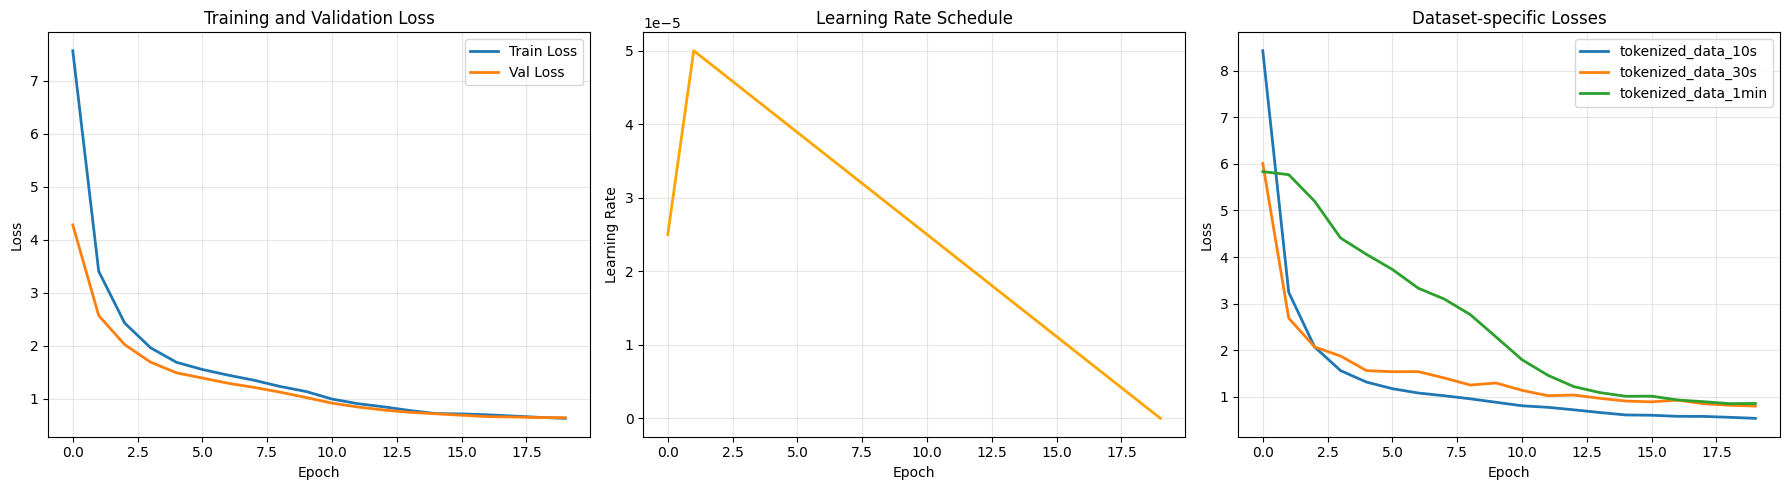

INFO:__main__:
INFO:__main__:Training completed successfully!
INFO:__main__:Final training loss: 0.6321
INFO:__main__:Final validation loss: 0.6442
INFO:__main__:Best validation loss: 0.6442



PRETRAINING COMPLETED SUCCESSFULLY!
Trained on 3 datasets:
  • tokenized_data_10s: 869 samples
  • tokenized_data_30s: 291 samples
  • tokenized_data_1min: 146 samples

Final training loss: 0.6321
Final validation loss: 0.6442
Model saved to: ../code/data/jupyter/llm/checkpoints/multi_dataset_pretrain


In [8]:
if __name__ == "__main__":
    main()